# Setup

This project requires Python 3.7 or above:

In [ ]:
import sys

assert sys.version_info >= (3, 7)

It also requires Scikit-Learn ≥ 1.0.1:

In [ ]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

Just like in the previous chapter, let's define the default font sizes to make the figures prettier:

In [ ]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

Y vamos a crear la carpeta `images/classification` (si no existe ya), y definir la función `save_fig()` que se utiliza a través de este notebook para guardar las figuras en alta resolución para el libro:

In [ ]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "classification"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# MNIST

MNIST: descargar conjuntos de datos populares.

---
El paquete `sklearn.datasets` contiene principalmente tres tipos de funciones:
* `fetch_` - `fetch_openml()` para descargar conjuntos de datos reales
* `load_*` para cargar pequeños conjuntos de datos de juguete incluidos en SK
* `make_` crear conjuntos de datos falsos, útiles para pruebas

In [ ]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

`fetch_openml()` por defecto devuelve las entradas como un Pandas-DataFrame y las etiquetas como una Serie Pandas. Es preferible configurar `as_frame` para obtener los datos como matrices Numpy en su lugar.

In [ ]:
# extra code – it's a bit too long
print(mnist.DESCR)

In [ ]:
mnist.keys()  # extra code – we only use data and target in this notebook

In [ ]:
X, y = mnist.data, mnist.target
X

In [ ]:
X.shape

In [ ]:
y

In [ ]:
y.shape

In [ ]:
28 * 28

Hay 70,000 imágenes, y cada imagen tiene 784 características. Es decir, 28*28 píxeles, y cada característica representa la intensidad de un píxel, de 0 a 255.

el siguiente código  es para formar la matriz y mostrarlo mediante la función de imshow(). `cmap="binary"` sirve para obtener un paca de color en escala grises donde 0 es blanco y 255 es negro.

In [ ]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="viridis")
    plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
save_fig("some_digit_plot")  # extra code
plt.show()

In [ ]:
y[0]

El parámetro `tight_layout=False` es crucial en este caso. La función tight_layout de Matplotlib ajusta automáticamente los márgenes para que todo quepa bien. Al desactivarlo, te aseguras de que el espaciado que definiste en el paso anterior (wspace=0, hspace=0) se mantenga sin que Matplotlib lo sobrescriba.

In [ ]:
# extra code – this cell generates and saves Figure 3–2
plt.figure(figsize=(10, 10))
for idx, image_data in enumerate(X[:100]):
    plt.subplot(10, 10, idx + 1)
    plot_digit(image_data)
plt.subplots_adjust(wspace=1, hspace=1)
save_fig("more_digits_plot", tight_layout=False)
plt.show()

---
Siempre debes crear un conjunto de prueba y apartarlo antes de inspeccionar los datos detenidamente.

In [ ]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

# Training a Binary Classifier

Quiero un clasificador binario, aquí escojo del conjunto _train y test_ aquellos que y son igual a "5".

In [ ]:
y_train_5 = (y_train == '5')  # True for all 5s, False for all other digits
y_test_5 = (y_test == '5')

In [ ]:
import pandas as pd
pd.DataFrame(y_train)

SGDClassifier: Clasificador de descenso de gradiente estocástico (SGC o GD estocástico) este clasificador es capaz de manejar eficientemente conjunto de datos muy grandes.

1. Se selecciona el modelo
2. Se entrena el modelo

In [ ]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

KeyboardInterrupt: 

3. Predice el modelo

In [ ]:
sgd_clf.predict([some_digit])

# Performance Measures

## Measuring Accuracy Using Cross-Validation (Medición de la precisión mediante validación cruzada)

Una buena forma de evaluar un modelo es utilizando la validación cruzada. La función `cross_val_score()` para evaluar el SGDClassifier, utilizando la validación cruzada k-fold con tres pliegues.
La validación cruzada `cv=3` de _k pliegues_ significa dividir el conjunto de entrenamiento en _k pliegues_ , en este caso son tres.
El parámetro `scoring` permite especificar la métrica de evaluación que se usará para juzgar el rendimiento del modelo en cada pliegue.
* "accuracy" : la precisión midel el porcentaje de predicciones correctas que hizo el modelo.
    * Cuando se usa? cundo el costo de un falso positivo es muy alto. Filtros de spam.
* "recall" : mide la capacidad del modelo para encontrar todas las instancias positivas.
    * Cuando se usa? cuando el costo de un falso negativo es muy alto. Detector de fraude, quieres un recall alto para no dejar pasar ninguna transacción fraudulenta.
* "F1-Score" : es un promedio (media armónica) de la precisión y el recall.
    * Cuando quieres una sola métrica que te dé una idea general del rendimiento especialmente con datos desbalanceados.
* ROC-AUC: Mide la capacidad del modelo para distinguir entre las clases. No se ve afectada por el desbalance de clases.
    * Cuando la clasificación de la clase positiva es más importante que la clase negativa, y quieres una métrica que resuma el rendimiento general del clasificador.

In [ ]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

Un clasificador ficticio que sólo clasifica cada imagen en la clase más frecuente, que no es igual a 5.

----
Este código sirve para realizar una valiadación cruzada estrificada manual. Su propósito es evaluar el rendiemiento del modelo de forma robusta, obteniendo una puntuación de precisión más confiable

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3)  # add shuffle=True if the dataset is not
                                       # already shuffled
for train_index, test_index in skfolds.split(X_train, y_train_5):
    # clone(sgd_clf) asegura que en cada iteración de la validación cruzada, el modelo se reinicia, volviendo a su estado original, para que el proceso de entrenamiento de cada pliegue sea independiente de los demás.
    clone_clf = clone(sgd_clf)
    # Esta es la forma estándar de crear subconjuntos de datos en NumPy y Pandas para realizar el entrenamiento y la validación cruzada
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    # El resultado, n_correct, es el número total de predicciones correctas para ese pliegue específico de la validación cruzada.
    n_correct = sum(y_pred == y_test_fold)
    #  Esta es la fórmula de la precisión. Divide el número de predicciones correctas (n_correct) entre el número total de predicciones (len(y_pred)).
    print(n_correct / len(y_pred))

In [ ]:
print(pd.DataFrame(y_train_5))
print(pd.DataFrame(X_train))
print(clone_clf)


# print(y_train_folds)
# print(y_test_fold)
# print(X_train_folds)
# print(X_test_fold)

print(pd.DataFrame(X_train_folds))
print(pd.DataFrame(y_train_folds))

print(pd.DataFrame(X_test_fold))
print(pd.DataFrame(y_test_fold))

Clasificador ficticio que solo clasifica cada imagen en la clase más frecuente, que en este caso es la clase negativa, aquellos que no son 5.
Crear un clasificador de referencia (o modelo dummy) para establecer una línea de base en el rendimiento de un modelo.
Este clasificador usa la clase más frecuente que encuentra en los datos de entrenamiento.

En el paso de `fit()`, el clasificador dummy no está aprendiendo a reconocer patrones complejos de los dígitos. Lo único que hace es contar cuántas veces aparece `True` (un 5) y cuántas veces aparece `False` (un no-5) en `y_train_5`. Como la clase `False` es mucho más común, el modelo "aprende" que debe predecir `False` la mayoría de las veces.

`dummy_clf.predict(X_train)`: El modelo hace sus predicciones en el conjunto de entrenamiento. Dado lo que aprendió en el paso anterior, todas sus predicciones serán `False`.

`any(...)`: La función `any()` verifica si al menos uno de los valores en una lista es `True`. Como todas las predicciones del modelo dummy son False, el resultado de esta línea será False.

**Nota**: El propósito de todo este código es mostrar que si tu modelo real no puede superar un rendimiento tan bajo como el del clasificador dummy, entonces tu modelo no está aprendiendo nada útil.


In [ ]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train)))

In [ ]:
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")

## Confusion Matrix

La idea general de una matriz de confusión es contar el número de veces que las instancias de la clase A se clasifican como clase B, para todos los pares A/B.

Primero podrás hacer predicciones sobre el conjunto de pruebas. Puedes utilizar la función `cross_val_predict()`

In [ ]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

Al igual que la función `cross_val_score()`, `cross_val_predict` realiza una validación cruzada de k pliegues, pero en lugar de devolveer las predicciones realizadas en cada pliegue de prueba. Esto significa que obtienes una predicción limpia para cada pliegue de prueba.

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train_5, y_train_pred)
cm

Cada fila de la matriz de confusión representa una clase real, mientras que cada columna representa una clase predicha.

```Python
[      No-5          ,       5         ]
[negativos           , falsos positivos]
[verdaderos negativos, positivos       ]
```
Un clasificador perfecto sólo tendría `verdaderos positivos` y `verdaderos negativos`, por lo que su matriz de confusión sólo tendría valores distintos de cero en su diagonal principal (de arriba a la izquierda a abajo a la derecha):

In [ ]:
y_train_perfect_predictions = y_train_5  # pretend we reached perfection
confusion_matrix(y_train_5, y_train_perfect_predictions)

La matriz de confusión te da mucha información, pero a veces puedes preferir una métrica más concisa. Una interesante es la exactitud de las predicciones positivas, que se denomina precisión del clasificador

Precisión
$
= TP/(TP+FP)
$
TP es el número de verdaderos positivos y FP es el númeor de falsos positivos


crear un clasificador que siempre haga predicciones negativas, excepto una única predicción positiva sobre la instancia en la que tiene más confianza. Si esta única predicción es correcta, entonces el clasificador tiene una precisión del 100% (precisión = 1/1 = 100%). Obviamente, un clasificador así no sería muy útil, ya que ignoraría todos los casos positivos excepto uno. Por eso, la precisión se suele utilizar junto con otra métrica llamada recuerdo, también llamada sensibilidad o tasa de verdaderos positivos (TPR): es la proporción de casos positivos que el clasificador detecta correctamente.

---

**Recall**

$
= TP/(TP+FN)
$

FN es, por supuesto, el número de falsos negativos.

Si la matriz de confusión te resulta confusa,

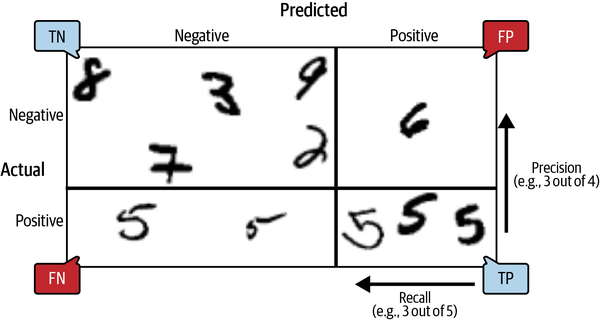

Ejemplo:
Necesitas ambas métricas para ver la historia completa. Por ejemplo, un modelo que tiene un 90% de precisión y un 80% de recall es mucho mejor que un modelo con 100% de precisión y solo 1% de recall, ya que el primer modelo es más efectivo en el mundo real

## Precision and Recall

Precisión:

Afirma que una imagen representa un 5, solo acierta el 83.7% de las veces. Sólo detecta el 65.1% de los 5s.

In [ ]:
from sklearn.metrics import precision_score, recall_score
precision_score(y_train_5, y_train_pred)  # == 3530 / (687 + 3530)

In [ ]:
# extra code – this cell also computes the precision: TP / (FP + TP)
cm[1, 1] / (cm[0, 1] + cm[1, 1])

Recall
---


In [ ]:
recall_score(y_train_5, y_train_pred)  # == 3530 / (1891 + 3530)

In [ ]:
# extra code – this cell also computes the recall: TP / (FN + TP)
cm[1, 1] / (cm[1, 0] + cm[1, 1])

A menudo es conveniente combinar la precisión y la recuperación en una única métrica llamada puntuaciónF1, especialmente cuando necesitas una única métrica para comparar dos clasificadores. La puntuaciónF1 es la media armónica de la precisión y la recuperación(ecuación 3-3). Mientras que la media normal trata todos los valores por igual, la media armónica da mucho más peso a los valores bajos.
La puntuación F1 resuelve este problema al darte un valor que solo será alto si ambas métricas son altas.

In [ ]:
from sklearn.metrics import f1_score

f1_score(y_train_5, y_train_pred)

In [ ]:
# extra code – this cell also computes the f1 score
cm[1, 1] / (cm[1, 1] + (cm[1, 0] + cm[0, 1]) / 2)

## Precision/Recall Trade-off

El compromiso presición/recuperación. Se trata de un dilema en el que, en la mayoría de los casos, no se puede maximizar ambas métricas al mismo tiempo.
El `F1-score` es una métrica útil para encontrar un equilibrio, pero no siempre es la mejor opción. La decisión de cuál priorizar depende del costo de los errores en el problema.
* Aumentar la precisión reduce la recuperación, y viceversa. Imagina un clasificador como un interruptor. Al hacerlo más sensible, aumenta la probabilidad de que detecte todos los casos positivos (alta recuperación), pero también es más probable que se equivoque y dé falsos positivos (baja precisión). Al hacerlo más estricto, aumenta la probabilidad de que sus predicciones positivas sean correctas (alta precisión), pero es más probable que se pierda algunos casos positivos reales (baja recuperación).


La puntuación F1 favorece a los clasificadores que tienen un buen balance entre la precisión y la recuperación. Es una métrica útil cuando ambos tipos de errores son importantes y necesitas un solo número para comparar modelos. Pero en los casos extremos que describe el texto, donde un tipo de error es mucho más costoso que el otro, es mejor mirar la precisión y la recuperación por separado.

En resumen, el umbral de decisión es un dial que puedes girar para priorizar la precisión (moviendo el umbral a la derecha) o la recuperación (moviendo el umbral a la izquierda), dependiendo de tu problema.

Cuando el modelo es "estricto": Sí, eso significa que tiene una alta precisión. El modelo es muy cauteloso y solo dice "sí" cuando está muy seguro. Esto minimiza los falsos positivos. Sin embargo, esta estrictez hace que el modelo se pierda algunos casos positivos reales, lo que reduce la sensibilidad.

Cuando bajas la estrictez: Bajar el umbral de decisión hace que el modelo sea más sensible. Por lo tanto, tu sensibilidad aumenta (porque detecta más casos positivos), pero tu precisión disminuye (porque se equivoca más y clasifica como positivos a más casos que no lo son)

---
Las puntuaciones de decisión que utiliza para hacer predicciones. En lugar de llamar al método `predict()` del clasificador, puedes llamar a su método `decision_function()`, que devuelve una puntuación para cada instancia, y luego utilizar el umbral que quieras para hacer predicciones basadas en esas puntuaciones:

Al acceder al umbral sirve para tener control total y flexibilidad sobre el comportamiento del modelo.
* El método `.predict()` no tiene control sobre el umbral
* El método `decision_function()` en cambio, te da el puntaje numérico que el modelo calculó para cada instancia. Este puntaje es la confianza que el modelo tiene en que el dato pertenece a la clase positiva.

El beneficio de tener los puntajes es que tú puedes decidir el umbral. Puedes escribir un código que diga:

* "Si el puntaje es mayor a 50, di que es positivo" (un umbral muy estricto para una alta precisión).

* "Si el puntaje es mayor a -20, di que es positivo" (un umbral bajo para una alta sensibilidad).

Esta flexibilidad te permite ajustar el modelo a las necesidades exactas de tu problema sin tener que volver a entrenarlo.

In [ ]:
some_digit_2 = X[1]
plot_digit(some_digit_2)
plt.show()


El valor de 2164.22 es la puntuación de decisión que el SGDClassifier le asigna a esa imagen. Este número indica la confianza que tiene el modelo de que la imagen es un 5.

* Una puntuación positiva indica que el modelo cree que la imagen es un 5.

Cuanto mayor es la puntuación (más lejos de cero), más confianza tiene el modelo en su predicción.

En este caso, una puntuación de `2164.22` es un valor muy alto, lo que significa que el `SGDClassifier` está extremadamente seguro de que el dígito que le diste es un 5. Mientras que `-5897.37359354` indica que no es un 5.

El Umbral de Decisión
Esta puntuación es lo que el modelo utiliza para tomar la decisión final. El SGDClassifier tiene un umbral de decisión interno (por defecto, en cero).

Como la puntuación 2164.22 es mucho mayor que cero, la predicción final del modelo sería True (es un 5).

Sin embargo, al tener acceso a este número, tú puedes decidir si quieres un modelo más estricto. Por ejemplo, podrías decidir que un dígito solo es un 5 si la puntuación es superior a 3000. En ese caso, la predicción para este dígito sería False, a pesar de que el modelo tenía una alta confianza.

In [ ]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

In [ ]:
y_scores_2 = sgd_clf.decision_function([some_digit_2])
y_scores_2

In [ ]:
threshold = 3000 # valor intercambiable
y_some_digit_pred = (y_scores > threshold)

In [ ]:
y_some_digit_pred

In [ ]:
# extra code – just shows that y_scores > 0 produces the same result as
#              calling predict()
y_scores > 0

In [ ]:
threshold = 3000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

El SGDClassifier utiliza un umbral igual a 0, por lo que el código anterior devuelve el mismo resultado que el método `predict()` (es decir, `True`).

Si subimos el umbral a 3000, disminuye la recuperación.

Cómo utilizar el umbral?

Con la función `cross_val_predict()` para obtener las puntuaciones de todas las instancias del conjunto de entrenamiento, pero esta vez especifica que quieres devolver puntuaciones de decisión en lugar de predicciones, con `method="decision_function"`.


In [ ]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,
                             method="decision_function")

Utiliza la función `precision_recall_curve()` para calcular la precisión y la recuperación para todos los umbrales posibles (la función añade una última precisión de 0 y una última recuperación de 1, correspondientes a un umbral infinito.

---
Calcular la curva de recuperación-precisión

El propósito de este proceso es obtener una visión completa del compromiso precisión/recuperación para tu modelo. Con las listas que te devuelve la función precision_recall_curve(), puedes crear un gráfico que te muestra cómo la precisión y la recuperación cambian a medida que ajustas el umbral.

In [ ]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

In [ ]:
print(precisions.argmax())

In [ ]:
plt.figure(figsize=(8, 4))  # extra code – it's not needed, just formatting
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")

# extra code – this section just beautifies and saves Figure 3–5
idx = (thresholds >= threshold).argmax()  # first index ≥ threshold
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
plt.axis([-50000, 50000, 0, 1])
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")
save_fig("precision_recall_vs_threshold_plot")

plt.show()

Puede que te preguntes por qué la curva de precisión es más irregular que la de recuperación en la Figura 3-5. La razón es que la precisión puede bajar a veces cuando subes el umbral (aunque en general subirá). La razón es que la precisión a veces puede bajar cuando subes el umbral (aunque en general subirá). Para entender por qué, vuelve a mirar la Figura 3-4 y fíjate en lo que ocurre cuando partes del umbral central y lo desplazas un solo dígito hacia la derecha: la precisión baja de 4/5 (80%) a 3/4 (75%). En cambio, el recuerdo sólo puede bajar cuando se aumenta el umbral, lo que explica por qué su curva parece suave.

---
Con este umbral, la precisión se acerca al 90% y la recuperación al 50%. Otra forma de seleccionar un buen equilibrio entre precisión y recuperación es trazar la precisión directamente frente a la recuperación, como se muestra en la Figura 3-6 (se muestra el mismo umbral):

¿Qué significan los números 90% y 48%?
Los números no son aleatorios; son el resultado directo de la elección del umbral.

* 90% de precisión: Esto es lo que lograste al ser muy estricto. De todas las veces que el detector sonó, el 90% de las veces fue oro de verdad. Esto suena muy bien.

* 48% de recuperación: Este es el costo de esa alta precisión. De todo el oro que había en el campo, el detector solo logró encontrar el 48%. El otro 52% se le escapó.

Puedes ver que la precisión empieza a caer bruscamente en torno al 80% de recuperación. Probablemente querrás elegir un punto de equilibrio entre precisión y recuperación justo antes de esa caída, por ejemplo, en torno al 60% de recuperación. Pero, por supuesto, la elección depende de tu proyecto.

In [ ]:
import matplotlib.patches as patches  # extra code – for the curved arrow

plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting

plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")

# extra code – just beautifies and saves Figure 3–6
plt.plot([recalls[idx], recalls[idx]], [0., precisions[idx]], "k:")
plt.plot([0.0, recalls[idx]], [precisions[idx], precisions[idx]], "k:")
plt.plot([recalls[idx]], [precisions[idx]], "ko",
         label="Point at threshold 3,000")
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.79, 0.60), (0.61, 0.78),
    connectionstyle="arc3,rad=.2",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.56, 0.62, "Higher\nthreshold", color="#333333")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")
save_fig("precision_vs_recall_plot")

plt.show()

Si alguien dice: "Alcancemos una precisión del 99%", debes preguntar: "¿Con qué precisión?".

En un detector de fraudes, si el 99.9% de las transacciones no son fraudulentas, un modelo que siempre prediga "no es fraude" tendrá una precisión altísima.

El "costo" en este caso sería una sensibilidad (recall) del 0%, lo cual es inaceptable. Aunque el modelo sea 99.9% preciso, no detectará ni un solo caso de fraude, que es el objetivo principal del modelo.

**Nota: "Un buen profesional siempre evalúa el rendimiento del modelo con un conjunto de métricas más completo, como la precisión y la sensibilidad"**

---
Si deseo aspirar a una precisión del 90%.
Puedes utilizar el método `argmax()` de la matriz Numpy. éste devuelve el primer índice del valor máximo, que en este caso significa el primer valor `True`:
El umbral debe tener un 90% de precisión, es decir, de cada 10 veces que suene, 9 deben ser una amenaza real.

In [ ]:
# el código busca todas las simulaciones y marca con True todos los puntos donde la precisión fue del 90% o superior
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

3370.0194... Toma el índice encontrado en el paso anterior y lo usa para seleccionar el valor exacto del umbral de la lista thresholds. Como los arrays de precisión, recuperación y umbrales están alineados, el índice que te da el 90% de precisión corresponde perfectamente al umbral necesario.

In [ ]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)

In [ ]:
precision_score(y_train_5, y_train_pred_90)

In [ ]:
recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)
recall_at_90_precision

## The ROC Curve

La curva _receiver operating characteristic_ (ROC) es otra herramienta común utilizada por clasificadores binarios. Es muy similar a la curva precisión/recuperación, pero en lugar de representar la precisión frente a la recuperación, la curva ROC representa la _tasa de verdaderos positivos_ (otro nombre para la recuperación) frente a la tasa de falsos positivos (FPR). La FPR (también llamada caída) es la proporción de casos negativos que se clasifican incorrectamente como positivos.
Es igual a 1-TNR (tasa de verdaderos negativos), que es la proporción de casos negativos que se clasifican correctamente como negativos. La TNR también se denomina _especificidad_. Por tanto, la curva ROC traza la _sensibilidad_ (recuerdo) frente a 1- _especificidad_.
* La TPR (tasa de verdaderos positivos), es la sensibilidad o `recall` (casos positivos reales, un TPR alto es deseable)
* La FPR (tasa de falsos positivos o verdaderos negativos) mide cuantos casos negativos el modelo identificó correctamente. De todos los casos negativos reales, ¿cuántos clasificó como positivos incorrectamente?. Un FPR bajo es deseable.



In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

El objetivo de estas líneas es encontrar las coordenadas exactas de la curva ROC que corresponden al umbral que garantiza tu 90% de precisión.
```
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]
```


Una vez más, hay una compensación: cuanto mayor es la recuperación (TPR), más falsos positivos (FPR) produce el clasificador. La línea de puntos representa la curva ROC de un clasificador puramente aleatorio; un buen clasificador se mantiene lo más alejado posible de esa línea (hacia la esquina superior izquierda).

Una forma de comparar clasificadores es medir el área bajo la curva (AUC). Un clasificador perfecto tendrá un AUC ROC igual a 1, mientras que un clasificador puramente aleatorio tendrá un AUC ROC igual a 0,5. Scikit-Learn proporciona una función para estimar el AUC ROC:

In [ ]:
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")

# extra code – just beautifies and saves Figure 3–7
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.20, 0.89), (0.07, 0.70),
    connectionstyle="arc3,rad=.4",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.12, 0.71, "Higher\nthreshold", color="#333333")
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)
save_fig("roc_curve_plot")

plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train_5, y_scores)

La curva ROC es tan parecida a la curva de precisión/recuperación (PR), quizá te preguntes cómo decidir cuál utilizar. **Como regla general, debes preferir la curva PR siempre que la clase positiva sea poco frecuente o cuando te preocupen más falsos positivos que falsos negativos. En caso contrario, utiliza la curva ROC.**
Si observas la curva ROC anterior (y la puntuación ROC AUC), puedes pensar que el clasificador es realmente bueno. Pero esto se debe principalmente a que hay pocos positivos (5s) en comparación con los negativos (no 5s). En cambio, la curva PR deja claro que el clasificador tiene margen de mejora: la curva podría estar realmente más cerca de la esquina superior derecha.

**Warning:** the following cell may take a few minutes to run.

`RandomForestClassifier`cuya curva PR y puntuación F1, podemos comparar con las del SGDClassifier.


La función `precision_recall_curve()` espera etiquetas y puntuaciones para cada instancia, por lo que tenemos que entrenar al clasificador de bosque aleatorio y hacer que asigne una puntuación a cada instancia. Pero la clase `RandomForestClassifier` no tiene un `métododecision_function()` debido a su funcionamiento (lo veremos en el Capítulo 7). Por suerte, tiene un método `predict_proba()` que devuelve probabilidades de clase para cada instancia, y podemos utilizar simplemente la probabilidad de la clase positiva como puntuación, así que funcionará bien.4 Podemos llamar a la función `cross_val_predict()` para entrenar al `RandomForestClassifier` mediante validación cruzada y hacer que prediga las probabilidades de clase para cada imagende la siguiente manera:
```
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3,
                                    method="predict_proba")
```

* El `SGDClassifier` se utiliza principalmente cuando se necesita velocidad y se tienen conjuntos de datos muy grandes (Big Data). Es un algoritmo lineal (similar a la Regresión Logística o Máquinas de Soporte Vectorial Lineales) optimizado para el rendimiento.

* El `RandomForestClassifier` se utiliza cuando se necesita alta precisión y se tienen conjuntos de datos medianos. Es un modelo de ensamble no lineal muy robusto y versátil.
Tiende a ofrecer una de las mejores precisiones "de fábrica" en la mayoría de los conjuntos de datos sin necesidad de un ajuste intensivo. Es muy robusto al sobreajuste.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(random_state=42)

`cross_val_predict()` para entrenar al RandomForestClassifier mediante validación cruzada y hacer que prediga las probabilidades de clase para cada imagen
El parámetro `method` especifica que tipo de resultado quieres que el estimador (tu clasificador), genere en cada iteración de la validación cruzada.
* `predict` devuelve la etiqueta de clase predicha final para cada instancia. Clasificaciones simples que solo requieren decisiones binarias como Accuracy, F1 o para generar la matriz de confusión.
* `predict_proba` devuelve la probabilidad de pertenecer a cada clase para cada instancia. Se usa para construir la Curva ROC y la Curva de Precisión/Recuperación (PR), y la AUC.
* `decision_function` devuelve la puntuación de confianza sin normalizar para cada isntancia. Esta puntuación no es una probabilidad, sino la "distancia" o "margen" del caso respecto al límite de decisión.
Es la alternativa a "predict_proba" cuando el modelo lo permite (como el SGDClassifier o SVC). Se utiliza para construir las Curvas ROC y PR, ya que también proporciona una métrica de confianza continua sobre la cual puede variar un umbral.
* `predict_log_proba` devuelve el logaritmo natural de la probabilidad de pertenecer a cada clase. Este método es menos común para la evaluación de curvas, pero es útil en ciertos modelos (como el Naive Bayes) o en tareas donde se requiere trabajar con logaritmos para evitar el underflow numérico (probabilidades extremadamente pequeñas que se redondean a cero).

In [ ]:
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3,
                                    method="predict_proba")

El modelo predice que la primera imagen es positiva con un 89% de probabilidad, y predice que la segunda imagen es negativa con un 99% de probabilidad. Como cada imagen es positiva o negativa, las probabilidades de cada fila suman 100%.

In [ ]:
y_probas_forest[:2]

Estas son probabilidades estimadas. Entre las imágenes que el modelo clasificó como positivas con una probabilidad de entre el 50 % y el 60 %, en realidad hay alrededor del 94 % de imágenes positivas:

* De todas las veces que el modelo estaba dudando (entre 50% y 60% de confianza), ¿cuántas veces tuvo razón? el 94%.
* Su función sirve para evaluar la calidad de las probabilidades que predice el modelo de Bosque Aleatorio. En términos sencillos, sirve para verificar si tu modelo es honesto sobre su propia confianza.

Este código te indica que tu modelo de Bosque Aleatorio tiende a ser demasiado cauteloso o pesimista (subestima su propia confianza), lo cual es un hallazgo importante si necesitas que las probabilidades de tu modelo sean fiables para la toma de decisiones.

Ejemplo:
* Riesgo Crediticio: No solo quieres saber si el cliente pagará, sino qué probabilidad real hay de que pague (ej. una probabilidad real del 94% justifica un préstamo mayor que una probabilidad real del 60%.
* El médico necesita saber si la probabilidad real de tener una enfermedad es del 94% para decidir si justifica un tratamiento costoso o invasivo.
Si la probabilidad estimada por el modelo es engañosa, la herramienta `sklearn.calibration` (mencionada en el texto anterior) se usa para calibrar y corregir estas puntuaciones.

In [ ]:
# Not in the code
idx_50_to_60 = (y_probas_forest[:, 1] > 0.50) & (y_probas_forest[:, 1] < 0.60)
print(f"{(y_train_5[idx_50_to_60]).sum() / idx_50_to_60.sum():.1%}")

In [ ]:
y_scores_forest = y_probas_forest[:, 1]
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(
    y_train_5, y_scores_forest)

Curva de Precisión/Recuperación (PR) y sirve para comparar visualmente el rendimiento de dos clasificadores (Random Forest y SGD) en una tarea de clasificación binaria desbalanceada.
Comparación de las curvas PR: el clasificador de bosque aleatorio es superior al clasificador SGD porque su curva PR está mucho más cerca de la esquina superior derecha, y tiene un AUC mayor.

La Curva PR muestra el compromiso (trade-off) entre estas dos métricas:

Eje Y: Precisión (Precision): La calidad de las predicciones positivas. Precisión

 $n=VP/(VP+FP)$

Ideal: Alta (cercana a 1.0).

Eje X: Recuperación (Recall / Sensibilidad): La capacidad para encontrar todos los casos positivos reales. Recuperaci
o
$
 n=VP/(VP+FN)
$

Ideal: Alta (cercana a 1.0).

Cuanto más se acerque una curva a la esquina superior derecha (1.0, 1.0), mejor es el clasificador.


In [ ]:
plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting

plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2,
         label="Random Forest")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")

# extra code – just beautifies and saves Figure 3–8
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")
save_fig("pr_curve_comparison_plot")

plt.show()

We could use `cross_val_predict(forest_clf, X_train, y_train_5, cv=3)` to compute `y_train_pred_forest`, but since we already have the estimated probabilities, we can just use the default threshold of 50% probability to get the same predictions much faster:

In [ ]:
y_train_pred_forest = y_probas_forest[:, 1] >= 0.5  # positive proba ≥ 50%
f1_score(y_train_5, y_train_pred_forest)

In [ ]:
roc_auc_score(y_train_5, y_scores_forest)

In [ ]:
precision_score(y_train_5, y_train_pred_forest)

In [ ]:
recall_score(y_train_5, y_train_pred_forest)

El texto explica que el RandomForestClassifier no solo es visualmente superior al SGDClassifier en la curva PR, sino que también lo confirman las métricas clave (F1 y ROC AUC).
1. Curva PR:
  La curv PR esta mucho más cerca de la esquina superior derecha significa que es capaz de lograr alta Precisión y alta recuperación.
2. Métricas de rendimiento clave
  * F1 (≈0.924)
  * ROC AUC (≈0.998)
  * Precisión: 99.1%
  * Recuperación (Recall): 86.6%
  * El F1-score de 0.924 es el promedio armónico de 0.991 y 0.866, lo cual indica un rendimiento global muy fuerte.

Esto significa que, al usar el umbral predeterminado (0.5):

El modelo es extremadamente preciso: De todas las veces que predijo que un número era un '5', acertó el 99.1% de las veces (muy pocos Falsos Positivos).

El modelo es muy sensible: Logró detectar el 86.6% de todos los '5s' reales que había en los datos (pocos Falsos Negativos).

# Multiclass Classification

Clasificadores binarios: distinguen entre dos clases (SGDClassifier y SVC).
Clasificadores multinomiales: distinguen entre más de dos clases (LogisticRegression, RandomForestClassifier y GaussianNB)

OvR: uno contra el resto

OvA: uno contra todos

OvO: uno contra uno

Agunos algoritmos como los clasificadores de Máquinas de Vectores de Soporte, se adaptan mal al tamaño del conjunto de entrenamiento. Para estos algoritmos se prefiere OvO por eficiencia. Para la mayoría de los algoritmos de clasificación binaria se prefiere OvR.

**_Scikit-Learn detecta cuando intentas utilizar un algoritmo de clasificación binario para una tarea de clasificación multiclase, y ejecuta automáticamente OvR u OvO, dependiendo del algoritmo._**

Las SVM no se escalan bien a grandes conjuntos de datos, por lo que solo entrenaremos en las primeras 2000 instancias; de lo contrario, esta sección tardará mucho tiempo en ejecutarse:

In [ ]:
from sklearn.svm import SVC

svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:2000], y_train[:2000])  # y_train, not y_train_5

Entrenamos el SVC utilizando las clases objetivo de 0 a 9. Como hay 10 clases, SKL utilizó la etsrategia OvO y entrenó 45 clasificadores binarios.

$ Número de clasificadores=
n×(n−1)/ 2 $

La principal ventaja de OvO es que cada clasificador sólo necesita entrenarse en la parte del conjunto de entrenamiento que contiene las dos clases que debe distinguir.

In [ ]:
svm_clf.predict([some_digit])

Si llamas al método `decision_function()`, verás que devuelve 10 puntuaciones por instancia: una por clase. Cada clase obtiene una puntuación igual al número de duelos ganados más o menos un pequeño ajuste (`máx. ±0,33`) para deshacer los empates, basándose en las puntuaciones del clasificador:

In [ ]:
some_digit_scores = svm_clf.decision_function([some_digit])
some_digit_scores.round(2)

Cuando se entrena un clasificador, almacena la lista de clases objetivo en el atributo `classes_` ordenadas por valor.

In [ ]:
class_id = some_digit_scores.argmax()
class_id

In [ ]:
svm_clf.classes_

In [ ]:
svm_clf.classes_[class_id]

Si desea que `decision_function()` devuelva las 45 puntuaciones, puede establecer el hiperparámetro `decision_function_shape` en `"ovo"`. El valor predeterminado es `"ovr"`, pero no se confunda: `SVC` siempre usa OvO para el entrenamiento. Este hiperparámetro solo determina si las 45 puntuaciones se agregan o no:
```
some_digit_scores_ovo = svm_clf.decision_function([some_digit])
```
Función: Llama al método `decision_function()` del SVC para obtener la puntuación de confianza para una sola instancia (`[some_digit]`, que es la imagen que estás tratando de clasificar).



In [ ]:
# extra code – shows how to get all 45 OvO scores if needed
svm_clf.decision_function_shape = "ovo"
some_digit_scores_ovo = svm_clf.decision_function([some_digit])
some_digit_scores_ovo.round(2)

Si quieres forzar a Scikit-Learn a utilizar uno contra uno o uno contra el resto, puedes utilizar las clases `OneVsOneClassifier` o `OneVsRestClassifier`. Simplemente crea una instancia y pasa un clasificador a su constructor (ni siquiera tiene que ser un clasificador binario). Por ejemplo, este código crea un clasificador multiclase utilizando la estrategia `OvR`, basado en un `SVC`

In [ ]:
from sklearn.multiclass import OneVsRestClassifier

ovr_clf = OneVsRestClassifier(SVC(random_state=42))
ovr_clf.fit(X_train[:2000], y_train[:2000])

In [ ]:
ovr_clf.predict([some_digit])

Número de clasificadores entrenados

In [ ]:
len(ovr_clf.estimators_)

Entrenar un `SDGClassifier` en un conjunto de datos multiclase y utilizarlo para hacer predicciones:

In [ ]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)
sgd_clf.predict([some_digit])

In [ ]:
sgd_clf.decision_function([some_digit]).round()

El clasificador no tiene mucha confianza en la predicción: casi todas las puntuaciones son muy negativas, mientras que la clase 3 tiene una puntuación de +1,824, y la clase 6 no está muy lejos, con -1,386. Como hay el mismo número de imágenes en cada clase, la métrica de precisión esta bien. Se puede utilizar `cross_val_score()` para evaluar el modelo.

`cross_val_score()` es una herramienta de evaluación que te da la "calificación real" del modelo, no una herramienta de mejora de la predicción.

**Warning:** the following two cells may take a few minutes each to run:

In [ ]:
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")

Obtiene más del 85,8% en todos los pliegues de prueba. Si utilizaras un clasificador aleatorio, obtendrías un 10% de precisión, así que no es una puntuación tan mala, pero aún puedes hacerlo mucho mejor. Simplemente escalando las entradas (como se explica en el Capítulo 2) aumenta la precisión por encima del 89,1%:

**La escalada no es magia, es hacer que los datos sean legibles y justos para el SGDClassifier, permitiéndole alcanzar su máximo rendimiento teórico.**
**Siempre debes usar la escalada de características (como StandardScaler) cuando trabajas con un SGDClassifier. Es un paso esencial para garantizar que el algoritmo pueda entrenarse y converger correctamente.**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype("float64"))
cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy")

# Error Analysis

Si has encontrado un modelo prometedor y quieres encontrar formas de mejorarlo. Una forma de hacerlo es analizar los tipos de errores que comete.
1. Observar la matriz de confusión:
    * Predicciones utilizando cross_val_predict()
    * Pasar las etiquetas a la función `confusion_matriz()`
    * Un diagrama de color de la matriz de confusión es fácil de analizar, para ello se utiliza `ConfusionMatrixDisplay.from_predictions()`

**Warning:** the following cell will take a few minutes to run:

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
plt.rc('font', size=9)  # extra code – make the text smaller
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.show()

Esta matriz de confusión tiene bastante buen aspecto: la mayoría de las imágenes están en la diagonal principal, lo que significa que se clasificaron correctamente. Observa que la celda de la diagonal de la fila 5 y la columna 5 parece ligeramente más oscura que los demás dígitos. Esto podría deberse a que el modelo cometió más errores en los 5s, o a que hay menos 5s en el conjunto de datos que en los otros dígitos. Por eso es importante normalizar la matriz de confusión dividiendo cada valor por el número total de imágenes de la clase (verdadera) correspondiente (es decir, dividir por la suma de la fila). Esto se puede hacer simplemente configurando `normalize="true"`. También podemos especificar el argumento `values_format=".0%"` para mostrar porcentajes sin decimales.

In [ ]:
plt.rc('font', size=10)  # extra code
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
                                        normalize="true", values_format=".0%")
plt.show()

Solo el 82% de las imágenes se clasificaron correctamente. El error más común que cometió el modelo con las imágenes de 5 fue clasificarlas erróneamente como 8: esto ocurrió con el 10% de todos los 5s.

Pero sólo el 2% de los 8 se clasificaron erróneamente como 5; ¡las matrices de confusión no suelen ser simétricas! Si te fijas bien, te darás cuenta de que muchos dígitos se han clasificado erróneamente como 8s, pero esto no es inmediatamente evidente en este diagrama. Si quieres que los errores destaquen más, puedes probar a poner un peso cero en las predicciones correctas.

Figura 3-10. Matriz de confusión sólo con errores, normalizada por filas (izquierda) y por columnas (derecha)

In [ ]:
sample_weight = (y_train_pred != y_train)
plt.rc('font', size=10)  # extra code
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
                                        sample_weight=sample_weight,
                                        normalize="true", values_format=".0%")
plt.show()

Let's put all plots in a couple of figures for the book:

In [ ]:
# extra code – this cell generates and saves Figure 3–9
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
plt.rc('font', size=9)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[0])
axs[0].set_title("Confusion matrix")
plt.rc('font', size=10)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[1],
                                        normalize="true", values_format=".0%")
axs[1].set_title("CM normalized by row")
save_fig("confusion_matrix_plot_1")
plt.show()

La columna de la clase 8 es ahora muy brillante, lo que confirma que muchas imágenes se clasificaron erróneamente como 8s. De hecho, ésta es la clasificación errónea más común para casi todas las clases. Pero ten cuidado al interpretar los porcentajes de este diagrama: recuerda que hemos excluido las predicciones correctas. Por ejemplo, el 36% de la fila 7, columna 9, **no significa que el 36% de todas las imágenes de 7s se clasificaran erróneamente como 9s. Significa que el 36% de los errores que cometió el modelo en las imágenes de 7 fueron clasificaciones erróneas como 9**. En realidad, sólo el 3% de las imágenes de 7 se clasificaron erróneamente como 9.

También es posible normalizar la matriz de confusión por columnas en lugar de por filas: si estableces `normalize="pred"`, obtendrás el diagrama de la derecha de la Figura 3-10. Por ejemplo, puedes ver que el 56% de los 7 mal clasificados son en realidad 9.

In [ ]:
# extra code – this cell generates and saves Figure 3–10
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
plt.rc('font', size=10)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[0],
                                        sample_weight=sample_weight,
                                        normalize="true", values_format=".0%")
axs[0].set_title("Errors normalized by row")
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[1],
                                        sample_weight=sample_weight,
                                        normalize="pred", values_format=".0%")
axs[1].set_title("Errors normalized by column")
save_fig("confusion_matrix_plot_2")
plt.show()
plt.rc('font', size=14)  # make fonts great again

El análisis de la matriz de confusión suele darte pistas sobre cómo mejorar tu clasificador. Observando estos gráficos, parece que tus esfuerzos deberían dedicarse a reducir los 8 falsos. Por ejemplo, podrías intentar reunir más datos de entrenamiento de dígitos que parezcan 8 (pero que no lo sean) para que el clasificador aprenda a distinguirlos de los 8 reales. O podrías diseñar nuevas características que ayudaran al clasificador; por ejemplo, escribir un algoritmo para contar el número de bucles cerrados (por ejemplo, 8 tiene dos, 6 tiene uno, 5 no tiene ninguno). O podrías preprocesar las imágenes (por ejemplo, utilizando Scikit-Image, Pillow u OpenCV) para que algunos patrones, como los bucles cerrados, destaquen más.

Analizar los errores individuales también puede ser una buena forma de obtener información sobre lo que está haciendo tu clasificador y por qué está fallando. Por ejemplo, tracemos ejemplos de 3s y 5s al estilo de una matriz de confusión

In [ ]:
cl_a, cl_b = '3', '5'
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]

In [ ]:
cl_aa, cl_bb = '5', '8'
X_aaa = X_train[(y_train == cl_aa) & (y_train_pred == cl_aa)]
X_aba = X_train[(y_train == cl_aa) & (y_train_pred == cl_bb)]
X_baa = X_train[(y_train == cl_bb) & (y_train_pred == cl_aa)]
X_bba = X_train[(y_train == cl_bb) & (y_train_pred == cl_bb)]

In [ ]:
# extra code – this cell generates and saves Figure 3–11
size = 100
pad = 0.2
plt.figure(figsize=(size, size))
for images, (label_col, label_row) in [(X_baa, (0, 0)), (X_bba, (1, 0)),
                                       (X_aaa, (0, 1)), (X_aba, (1, 1))]:
    for idx, image_data in enumerate(images[:size*size]):
        x = idx % size + label_col * (size + pad)
        y = idx // size + label_row * (size + pad)
        plt.imshow(image_data.reshape(28, 28), cmap="binary",
                   extent=(x, x + 1, y, y + 1))
plt.xticks([size / 2, size + pad + size / 2], [str(cl_aa), str(cl_bb)])
plt.yticks([size / 2, size + pad + size / 2], [str(cl_bb), str(cl_aa)])
plt.plot([size + pad / 2, size + pad / 2], [0, 2 * size + pad], "k:")
plt.plot([0, 2 * size + pad], [size + pad / 2, size + pad / 2], "k:")
plt.axis([0, 2 * size + pad, 0, 2 * size + pad])
plt.xlabel("Predicted label")
plt.ylabel("True label")
save_fig("error_analysis_digits_plot")
plt.show()

In [ ]:
# extra code – this cell generates and saves Figure 3–11
size = 5
pad = 0.2
plt.figure(figsize=(size, size))
for images, (label_col, label_row) in [(X_ba, (0, 0)), (X_bb, (1, 0)),
                                       (X_aa, (0, 1)), (X_ab, (1, 1))]:
    for idx, image_data in enumerate(images[:size*size]):
        x = idx % size + label_col * (size + pad)
        y = idx // size + label_row * (size + pad)
        plt.imshow(image_data.reshape(28, 28), cmap="binary",
                   extent=(x, x + 1, y, y + 1))
plt.xticks([size / 2, size + pad + size / 2], [str(cl_a), str(cl_b)])
plt.yticks([size / 2, size + pad + size / 2], [str(cl_b), str(cl_a)])
plt.plot([size + pad / 2, size + pad / 2], [0, 2 * size + pad], "k:")
plt.plot([0, 2 * size + pad], [size + pad / 2, size + pad / 2], "k:")
plt.axis([0, 2 * size + pad, 0, 2 * size + pad])
plt.xlabel("Predicted label")
plt.ylabel("True label")
save_fig("error_analysis_digits_plot")
plt.show()

Note: there are several other ways you could code a plot like this one, but it's a bit hard to get the axis labels right:
* using [nested GridSpecs](https://matplotlib.org/stable/gallery/subplots_axes_and_figures/gridspec_nested.html)
* merging all the digits in each block into a single image (then using 2×2 subplots). For example:
    ```python
    X_aa[:25].reshape(5, 5, 28, 28).transpose(0, 2, 1, 3).reshape(5 * 28, 5 * 28)
    ```
* using [subfigures](https://matplotlib.org/stable/gallery/subplots_axes_and_figures/subfigures.html) (since Matplotlib 3.4)

En conclusión: Como puedes ver, algunos de los dígitos que el clasificador obtiene mal (es decir, en los bloques inferior izquierdo y superior derecho) están tan mal escritos que incluso un humano tendría problemas para clasificarlos. Sin embargo, la mayoría de las imágenes mal clasificadas nos parecen errores evidentes.

Utilizamos un sencillo SGDClassifier, que no es más que un modelo lineal: todo lo que hace es asignar un peso por clase a cada píxel, y cuando ve una nueva imagen sólo suma las intensidades ponderadas de los píxeles para obtener una puntuación para cada clase. Como los 3s y los 5s sólo se diferencian en unos pocos píxeles, este modelo los confundirá fácilmente.

En otras palabras, este clasificador es bastante sensible al desplazamiento y la rotación de la imagen. Una forma de reducir la confusión 3/5 es preprocesar las imágenes para asegurarse de que están bien centradas y no demasiado rotadas.

Aumentar el conjunto de entrenamiento con variantes ligeramente desplazadas y rotadas de las imágenes de entrenamiento. Esto obligará al modelo a aprender a ser más tolerante a dichas variaciones. Esto se denomina aumento de datos.

# Multilabel Classification

In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

# el número es mayor a 7 si (true), no (false)
y_train_large = (y_train >= '7')
# Convierte las etiquetas 'x' en números enteros con 'int8';
# el operador %2 es el operador que divide entre 2 si comprueba que el resto de la division es ==1
# la condición =1 o impar (True), =0 o par (False)
y_train_odd = (y_train.astype('int8') % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

El dígito 5 no es mayor a 7 y es número impar.

In [ ]:
knn_clf.predict([some_digit])

Hay muchas formas de evaluar un clasificador multietiqueta, un enfoque es medir la puntuación F1 para cada etiqueta individual y luego simplemente calcular la puntuación media.

**Warning**: the following cell may take a few minutes to run:

Opciones de "average":
* `none`: devuelve un arreglo con la métrica calculada para cada clase o etiqueta individualmente. Cuando prefieras ver cómo se dempeño el modelo por cada una de las clases.
* `micro`: calcula la métrica globalmente contando el total de verdaderos positivos, falsos negativos, y falsos positivos a través de todas las clases o que se asemeje a la exactitud. Cuando hay un desbalance de clases significativo y quieres que las clases mayoritarias dominan la métrica. Tiende a ser menos informativo que 'macro' o 'weighted'
* `weighted` cuando quieres un promedio fiel a la distribución real de los datos, ejemplo su tienes muchas fotos de Alicia que de Bob o Charlie, puede que quieras dar más peso a la puntuacion del clasificador de las fotos de Alicia.
* `macro`: igualdad entre todas las clases. Cuando el rendimeinto en todas las clases es igualmente importante.

In [ ]:
from sklearn.metrics import f1_score

y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)
f1_score(y_multilabel, y_train_knn_pred, average="macro")

In [ ]:
# código adicional: muestra que obtenemos una mejora insignificante en el rendimiento cuando
# establecemos average="weighted" porque las clases ya están bastante
# bien equilibradas.
f1_score(y_multilabel, y_train_knn_pred, average="weighted")

Clasificador que no admite de forma nativa la clasificación multietiqueta, como `SVC`, una estrategia posible es entrenar un modelo por etiqueta, o sea que no sepa si el dígito es >= a 7 o si es par o impar .
Sin embargo, esta estrategia puede tener dificultades para captar las dependencias entre etiquetas. La predicción del elemento A puede ser una pista muy útil para el elemento B.

Para resolver este problema, los modelos pueden organizarse en cadena: cuando un modelo hace una predicción, utiliza las características de entrada más todas las predicciones de los modelos que le preceden en la cadena.

Si estableces el hiperparámetro `cv` utilizará la validación cruzada para obtener predicciones "limpias" (fuera de la muestra) de cada modelo entrenado para cada instancia del conjunto de entrenamiento, y estas predicciones se utilizarán para entrenar todos los modelos posteriores de la cadena.

In [ ]:
from sklearn.multioutput import ClassifierChain

chain_clf = ClassifierChain(SVC(), cv=3, random_state=42)
chain_clf.fit(X_train[:2000], y_multilabel[:2000])

In [ ]:
chain_clf.predict([some_digit])

# Multioutput Classification

Clasificación multisalida-multiclase o multisalida. Es una generalizacion de la clasificación multietiqueta en la que cada etiquera puede ser multiclase (más de dos valores posibles).

Eliminar el ruido de las imágenes.
* Input: imagen de dígitos con ruido,
* Output: salida de imagen de dígitos limpia.

* Multietiqueta: la salida es una imagen entera, dado que 28x28 pixeles, el clasificador hace 784 predicciones a la vez, una por pixel.
* Multiclase: la salida de cada píxel es una intensidad que va de 0 a 255. Por tanto, cada una de esas 784 etiquetas tien 256 valores posibles.

`noise`: se crea un arreglo de ruido donde cada píxel de cada imagen recibe un valor aleatorio entre 0 y 99.

`X_train_mod`: se añade el ruido a las imágenes originales de entrenamiento.

`y_train_mod`: las etiquetas objetivo son las imágenes originales sin ruido.

Predecir un valor continuo como la intensidad de un píxel (de 0 a 255) **es técnicamente una tarea de regresión**, no de clasificación (que predice categorías discretas).

Sin embargo, dado que solo hay 256 valores posibles (de 0 a 255), el problema puede ser tratado como una tarea de clasificación con 256 categorías.


In [ ]:
np.random.seed(42)  # to make this code example reproducible
noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise
noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise
y_train_mod = X_train
y_test_mod = X_test

In [ ]:
import numpy as np
# Configuración para que NumPy no omita columnas ni filas
np.set_printoptions(threshold=np.inf, linewidth=1000)
# Ejemplo: X_train_mod[0] es la primera imagen ruidosa (784 píxeles)
print(y_test_mod[0])

# O la primera imagen limpia, que es la que te confundía con ceros:
# print(y_train_mod[0])



In [ ]:
# Restablecer la configuración predeterminada
np.set_printoptions(threshold=1000, linewidth=75)

In [ ]:
# extra code – this cell generates and saves Figure 3–12
plt.subplot(121); plot_digit(X_test_mod[0])
plt.subplot(122); plot_digit(y_test_mod[0])
save_fig("noisy_digit_example_plot")
plt.show()

In [ ]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_mod, y_train_mod)

In [ ]:
clean_digit = knn_clf.predict([X_test_mod[53]])
plot_digit(clean_digit)
save_fig("cleaned_digit_example_plot")  # extra code – saves Figure 3–13
plt.show()

# Exercise solutions

## 1. An MNIST Classifier With Over 97% Accuracy

Exercise: _Try to build a classifier for the MNIST dataset that achieves over 97% accuracy on the test set. Hint: the `KNeighborsClassifier` works quite well for this task; you just need to find good hyperparameter values (try a grid search on the `weights` and `n_neighbors` hyperparameters)._

Let's start with a simple K-Nearest Neighbors classifier and measure its performance on the test set. This will be our baseline:

In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_train)
baseline_accuracy = knn_clf.score(X_test, y_test)
baseline_accuracy

Great! A regular KNN classifier with the default hyperparameters is already very close to our goal.

Let's see if tuning the hyperparameters can help. To speed up the search, let's train only on the first 10,000 images:

El valor de `cv=5` o `cv=10` se ha demostrado empíricamente como el punto ideal donde se obtiene una evaluación de rendimiento razonablemente precisa sin forzar al proceso a entrenar una cantidad excesiva de modelos.

La finalidad es obtener el clasificador KNeighborsClassifier que tenga el mejor rendimiento en tu tarea de clasificación, sin depender de la suerte o de la intuición manual.

Una vez que el código termina, puedes acceder a la mejor configuración encontrada con `grid_search.best_params_` y al modelo entrenado y optimizado con `grid_search.best_estimator_`.
En resumen, el parámetro `cv =` 5 y 10 son el punto de partida seguro, pero siempre ajustas este número basándote en el tamaño y la complejidad de tu proyecto.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = [{'weights': ["uniform", "distance"], 'n_neighbors': [3, 4, 5, 6]}]

knn_clf = KNeighborsClassifier()
grid_search = GridSearchCV(knn_clf, param_grid, cv=5)
grid_search.fit(X_train[:10_000], y_train[:10_000])

In [ ]:
grid_search.best_params_

In [ ]:
grid_search.best_score_

The score dropped, but that was expected since we only trained on 10,000 images. So let's take the best model and train it again on the full training set:

In [ ]:
grid_search.best_estimator_.fit(X_train, y_train)
tuned_accuracy = grid_search.score(X_test, y_test)
tuned_accuracy

We reached our goal of 97% accuracy! 🥳

## 2. Data Augmentation

Exercise: _Write a function that can shift an MNIST image in any direction (left, right, up, or down) by one pixel. You can use the `shift()` function from the `scipy.ndimage` module. For example, `shift(image, [2, 1], cval=0)` shifts the image two pixels down and one pixel to the right. Then, for each image in the training set, create four shifted copies (one per direction) and add them to the training set. Finally, train your best model on this expanded training set and measure its accuracy on the test set. You should observe that your model performs even better now! This technique of artificially growing the training set is called _data augmentation_ or _training set expansion_._

Let's try augmenting the MNIST dataset by adding slightly shifted versions of each image.

In [ ]:
from scipy.ndimage import shift

`shift_image`: desplazar o mover una imagen, parte de la técnica llamada aumento de datos.

`image`: array bidimensional para trabajar con una matriz

`dx`: mover la imagen horizontal

`dy`: mover la imagen vertical


In [ ]:
def shift_image(image, dx, dy):
    image = image.reshape((28, 28))
    shifted_image = shift(image, [dy, dx], cval=0, mode="constant")
    return shifted_image.reshape([-1])

Let's see if it works:

In [ ]:
image = X_train[1000]  # some random digit to demo
shifted_image_down = shift_image(image, 0, 5)
shifted_image_left = shift_image(image, -5, 0)

plt.figure(figsize=(12, 3))
plt.subplot(131)
plt.title("Original")
plt.imshow(image.reshape(28, 28),
           interpolation="nearest", cmap="Greys")
plt.subplot(132)
plt.title("Shifted down")
plt.imshow(shifted_image_down.reshape(28, 28),
           interpolation="nearest", cmap="Greys")
plt.subplot(133)
plt.title("Shifted left")
plt.imshow(shifted_image_left.reshape(28, 28),
           interpolation="nearest", cmap="Greys")
plt.show()

Looks good! Now let's create an augmented training set by shifting every image left, right, up and down by one pixel:

In [ ]:
X_train_augmented = [image for image in X_train]
y_train_augmented = [label for label in y_train]

for dx, dy in ((-1, 0), (1, 0), (0, 1), (0, -1)):
    for image, label in zip(X_train, y_train):
        X_train_augmented.append(shift_image(image, dx, dy))
        y_train_augmented.append(label)

X_train_augmented = np.array(X_train_augmented)
y_train_augmented = np.array(y_train_augmented)

Let's shuffle the augmented training set, or else all shifted images will be grouped together:

In [ ]:
shuffle_idx = np.random.permutation(len(X_train_augmented))
X_train_augmented = X_train_augmented[shuffle_idx]
y_train_augmented = y_train_augmented[shuffle_idx]

Now let's train the model using the best hyperparameters we found in the previous exercise:

In [ ]:
knn_clf = KNeighborsClassifier(**grid_search.best_params_)

In [ ]:
knn_clf.fit(X_train_augmented, y_train_augmented)

**Warning**: the following cell may take a few minutes to run:

In [ ]:
augmented_accuracy = knn_clf.score(X_test, y_test)
augmented_accuracy

By simply augmenting the data, we've got a 0.5% accuracy boost. Perhaps it does not sound so impressive, but it actually means that the error rate dropped significantly:

In [ ]:
error_rate_change = (1 - augmented_accuracy) / (1 - tuned_accuracy) - 1
print(f"error_rate_change = {error_rate_change:.0%}")

The error rate dropped quite a bit thanks to data augmentation.

## 3. Tackle the Titanic dataset

Exercise: _Tackle the Titanic dataset. A great place to start is on [Kaggle](https://www.kaggle.com/c/titanic). Alternatively, you can download the data from https://homl.info/titanic.tgz and unzip this tarball like you did for the housing data in Chapter 2. This will give you two CSV files: _train.csv_ and _test.csv_ which you can load using `pandas.read_csv()`. The goal is to train a classifier that can predict the `Survived` column based on the other columns._

Let's fetch the data and load it:

In [ ]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_titanic_data():
    tarball_path = Path("datasets/titanic.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/titanic.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as titanic_tarball:
            titanic_tarball.extractall(path="datasets")
    return [pd.read_csv(Path("datasets/titanic") / filename)
            for filename in ("train.csv", "test.csv")]

In [ ]:
train_data, test_data = load_titanic_data()

The data is already split into a training set and a test set. However, the test data does *not* contain the labels: your goal is to train the best model you can on the training data, then make your predictions on the test data and upload them to Kaggle to see your final score.

Let's take a peek at the top few rows of the training set:

In [ ]:
train_data.head()

The attributes have the following meaning:
* **PassengerId**: a unique identifier for each passenger
* **Survived**: that's the target, 0 means the passenger did not survive, while 1 means he/she survived.
* **Pclass**: passenger class.
* **Name**, **Sex**, **Age**: self-explanatory
* **SibSp**: how many siblings & spouses of the passenger aboard the Titanic.
* **Parch**: how many children & parents of the passenger aboard the Titanic.
* **Ticket**: ticket id
* **Fare**: price paid (in pounds)
* **Cabin**: passenger's cabin number
* **Embarked**: where the passenger embarked the Titanic

The goal is to predict whether or not a passenger survived based on attributes such as their age, sex, passenger class, where they embarked and so on.

Let's explicitly set the `PassengerId` column as the index column:

In [ ]:
train_data = train_data.set_index("PassengerId")
test_data = test_data.set_index("PassengerId")

Let's get more info to see how much data is missing:

In [ ]:
train_data.info()

In [ ]:
train_data[train_data["Sex"]=="female"]["Age"].median()

Okay, the **Age**, **Cabin** and **Embarked** attributes are sometimes null (less than 891 non-null), especially the **Cabin** (77% are null). We will ignore the **Cabin** for now and focus on the rest. The **Age** attribute has about 19% null values, so we will need to decide what to do with them. Replacing null values with the median age seems reasonable. We could be a bit smarter by predicting the age based on the other columns (for example, the median age is 37 in 1st class, 29 in 2nd class and 24 in 3rd class), but we'll keep things simple and just use the overall median age.

The **Name** and **Ticket** attributes may have some value, but they will be a bit tricky to convert into useful numbers that a model can consume. So for now, we will ignore them.

Let's take a look at the numerical attributes:

In [ ]:
train_data.describe()

* Yikes, only 38% **Survived**! 😭 That's close enough to 40%, so accuracy will be a reasonable metric to evaluate our model.
* The mean **Fare** was £32.20, which does not seem so expensive (but it was probably a lot of money back then).
* The mean **Age** was less than 30 years old.

Let's check that the target is indeed 0 or 1:

In [ ]:
train_data["Survived"].value_counts()

Now let's take a quick look at all the categorical attributes:

In [ ]:
train_data["Pclass"].value_counts()

In [ ]:
train_data["Sex"].value_counts()

In [ ]:
train_data["Embarked"].value_counts()

The Embarked attribute tells us where the passenger embarked: C=Cherbourg, Q=Queenstown, S=Southampton.

Now let's build our preprocessing pipelines, starting with the pipeline for numerical attributes:

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

Now we can build the pipeline for the categorical attributes:

In [ ]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

Note: the `sparse` hyperparameter below was renamed to `sparse_output`.

In [ ]:
cat_pipeline = Pipeline([
        ("ordinal_encoder", OrdinalEncoder()),
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("cat_encoder", OneHotEncoder(sparse_output=False)),
    ])

Finally, let's join the numerical and categorical pipelines:

In [ ]:
from sklearn.compose import ColumnTransformer

num_attribs = ["Age", "SibSp", "Parch", "Fare"]
cat_attribs = ["Pclass", "Sex", "Embarked"]

preprocess_pipeline = ColumnTransformer([
        ("num", num_pipeline, num_attribs),
        ("cat", cat_pipeline, cat_attribs),
    ])

Cool! Now we have a nice preprocessing pipeline that takes the raw data and outputs numerical input features that we can feed to any Machine Learning model we want.

In [ ]:
X_train = preprocess_pipeline.fit_transform(train_data)
X_train

Let's not forget to get the labels:

In [ ]:
y_train = train_data["Survived"]

We are now ready to train a classifier. Let's start with a `RandomForestClassifier`:

In [ ]:
forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
forest_clf.fit(X_train, y_train)

Great, our model is trained, let's use it to make predictions on the test set:

In [ ]:
X_test = preprocess_pipeline.transform(test_data)
y_pred = forest_clf.predict(X_test)

And now we could just build a CSV file with these predictions (respecting the format expected by Kaggle), then upload it and hope for the best. But wait! We can do better than hope. Why don't we use cross-validation to have an idea of how good our model is?

In [ ]:
forest_scores = cross_val_score(forest_clf, X_train, y_train, cv=10)
forest_scores.mean()

Okay, not too bad! Looking at the [leaderboard](https://www.kaggle.com/c/titanic/leaderboard) for the Titanic competition on Kaggle, you can see that our score is in the top 2%, woohoo! Some Kagglers reached 100% accuracy, but since you can easily find the [list of victims](https://www.encyclopedia-titanica.org/titanic-victims/) of the Titanic, it seems likely that there was little Machine Learning involved in their performance! 😆

Let's try an `SVC`:

In [ ]:
from sklearn.svm import SVC

svm_clf = SVC(gamma="auto")
svm_scores = cross_val_score(svm_clf, X_train, y_train, cv=10)
svm_scores.mean()

Great! This model looks better.

But instead of just looking at the mean accuracy across the 10 cross-validation folds, let's plot all 10 scores for each model, along with a box plot highlighting the lower and upper quartiles, and "whiskers" showing the extent of the scores (thanks to Nevin Yilmaz for suggesting this visualization). Note that the `boxplot()` function detects outliers (called "fliers") and does not include them within the whiskers. Specifically, if the lower quartile is $Q_1$ and the upper quartile is $Q_3$, then the interquartile range $IQR = Q_3 - Q_1$ (this is the box's height), and any score lower than $Q_1 - 1.5 \times IQR$ is a flier, and so is any score greater than $Q3 + 1.5 \times IQR$.

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot([1]*10, svm_scores, ".")
plt.plot([2]*10, forest_scores, ".")
plt.boxplot([svm_scores, forest_scores], labels=("SVM", "Random Forest"))
plt.ylabel("Accuracy")
plt.show()

The random forest classifier got a very high score on one of the 10 folds, but overall it had a lower mean score, as well as a bigger spread, so it looks like the SVM classifier is more likely to generalize well.

To improve this result further, you could:
* Compare many more models and tune hyperparameters using cross validation and grid search,
* Do more feature engineering, for example:
  * Try to convert numerical attributes to categorical attributes: for example, different age groups had very different survival rates (see below), so it may help to create an age bucket category and use it instead of the age. Similarly, it may be useful to have a special category for people traveling alone since only 30% of them survived (see below).
  * Replace **SibSp** and **Parch** with their sum.
  * Try to identify parts of names that correlate well with the **Survived** attribute.
  * Use the **Cabin** column, for example take its first letter and treat it as a categorical attribute.

In [ ]:
train_data["AgeBucket"] = train_data["Age"] // 15 * 15
train_data[["AgeBucket", "Survived"]].groupby(['AgeBucket']).mean()

In [ ]:
train_data["RelativesOnboard"] = train_data["SibSp"] + train_data["Parch"]
train_data[["RelativesOnboard", "Survived"]].groupby(
    ['RelativesOnboard']).mean()

## 4. Spam classifier

Exercise: _Build a spam classifier (a more challenging exercise):_

* _Download examples of spam and ham from [Apache SpamAssassin's public datasets](https://homl.info/spamassassin)._
* _Unzip the datasets and familiarize yourself with the data format._
* _Split the datasets into a training set and a test set._
* _Write a data preparation pipeline to convert each email into a feature vector. Your preparation pipeline should transform an email into a (sparse) vector that indicates the presence or absence of each possible word. For example, if all emails only ever contain four words, "Hello," "how," "are," "you," then the email "Hello you Hello Hello you" would be converted into a vector [1, 0, 0, 1] (meaning [“Hello" is present, "how" is absent, "are" is absent, "you" is present]), or [3, 0, 0, 2] if you prefer to count the number of occurrences of each word._

_You may want to add hyperparameters to your preparation pipeline to control whether or not to strip off email headers, convert each email to lowercase, remove punctuation, replace all URLs with "URL," replace all numbers with "NUMBER," or even perform _stemming_ (i.e., trim off word endings; there are Python libraries available to do this)._

_Finally, try out several classifiers and see if you can build a great spam classifier, with both high recall and high precision._

In [ ]:
import tarfile

def fetch_spam_data():
    spam_root = "http://spamassassin.apache.org/old/publiccorpus/"
    ham_url = spam_root + "20030228_easy_ham.tar.bz2"
    spam_url = spam_root + "20030228_spam.tar.bz2"

# Objeto de ruta
    spam_path = Path() / "datasets" / "spam"

    # crear directorio 'parents=True' si no existe lo crea, 'exist_ok=True' Sie l directorio dataset/spam ya existe, no lanza un error
    spam_path.mkdir(parents=True, exist_ok=True)

    #crea pares de conjuntos de datos. En cada iteracion, desempaqueta los valores, dir_name, tar_name y url.
    for dir_name, tar_name, url in (("easy_ham", "ham", ham_url),
                                    ("spam", "spam", spam_url)):

        # Retorna True si path es un directorio existing.
        # Esto sigue los enlaces simbólicos, por lo que tanto islink()
        # como isdir() pueden ser verdaderos para la misma ruta.
        if not (spam_path / dir_name).is_dir():
            path = (spam_path / tar_name).with_suffix(".tar.bz2")
            print("Downloading", path)

            urllib.request.urlretrieve(url, path)
            tar_bz2_file = tarfile.open(path)
            tar_bz2_file.extractall(path=spam_path)
            tar_bz2_file.close()
    return [spam_path / dir_name for dir_name in ("easy_ham", "spam")]

In [ ]:
import urllib
from pathlib import Path
ham_dir, spam_dir = fetch_spam_data()

Next, let's load all the emails:

In [ ]:
ham_filenames = [f for f in sorted(ham_dir.iterdir()) if len(f.name) > 20]
spam_filenames = [f for f in sorted(spam_dir.iterdir()) if len(f.name) > 20]

In [ ]:
len(ham_filenames)

In [ ]:
len(spam_filenames)

We can use Python's `email` module to parse these emails (this handles headers, encoding, and so on):

In [ ]:
import email
import email.policy

def load_email(filepath):
    with open(filepath, "rb") as f:
        return email.parser.BytesParser(policy=email.policy.default).parse(f)

In [ ]:
ham_emails = [load_email(filepath) for filepath in ham_filenames]
spam_emails = [load_email(filepath) for filepath in spam_filenames]

Let's look at one example of ham and one example of spam, to get a feel of what the data looks like:

In [ ]:
print(ham_emails[1].get_content().strip())

In [ ]:
print(spam_emails[6].get_content().strip())

Some emails are actually multipart, with images and attachments (which can have their own attachments). Let's look at the various types of structures we have:

In [ ]:
def get_email_structure(email):
    if isinstance(email, str):
        return email
    payload = email.get_payload()
    if isinstance(payload, list):
        multipart = ", ".join([get_email_structure(sub_email)
                               for sub_email in payload])
        return f"multipart({multipart})"
    else:
        return email.get_content_type()

In [ ]:
from collections import Counter

def structures_counter(emails):
    structures = Counter()
    for email in emails:
        structure = get_email_structure(email)
        structures[structure] += 1
    return structures

In [ ]:
structures_counter(ham_emails).most_common()

In [ ]:
structures_counter(spam_emails).most_common()

It seems that the ham emails are more often plain text, while spam has quite a lot of HTML. Moreover, quite a few ham emails are signed using PGP, while no spam is. In short, it seems that the email structure is useful information to have.

Now let's take a look at the email headers:

In [ ]:
for header, value in spam_emails[0].items():
    print(header, ":", value)

There's probably a lot of useful information in there, such as the sender's email address (12a1mailbot1@web.de looks fishy), but we will just focus on the `Subject` header:

In [ ]:
spam_emails[0]["Subject"]

Okay, before we learn too much about the data, let's not forget to split it into a training set and a test set:

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

X = np.array(ham_emails + spam_emails, dtype=object)
y = np.array([0] * len(ham_emails) + [1] * len(spam_emails))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)

Okay, let's start writing the preprocessing functions. First, we will need a function to convert HTML to plain text. Arguably the best way to do this would be to use the great [BeautifulSoup](https://www.crummy.com/software/BeautifulSoup/) library, but I would like to avoid adding another dependency to this project, so let's hack a quick & dirty solution using regular expressions (at the risk of [un̨ho͞ly radiańcé destro҉ying all enli̍̈́̂̈́ghtenment](https://stackoverflow.com/a/1732454/38626)). The following function first drops the `<head>` section, then converts all `<a>` tags to the word HYPERLINK, then it gets rid of all HTML tags, leaving only the plain text. For readability, it also replaces multiple newlines with single newlines, and finally it unescapes html entities (such as `&gt;` or `&nbsp;`):

In [ ]:
import re
from html import unescape

def html_to_plain_text(html):
    text = re.sub('<head.*?>.*?</head>', '', html, flags=re.M | re.S | re.I)
    text = re.sub('<a\s.*?>', ' HYPERLINK ', text, flags=re.M | re.S | re.I)
    text = re.sub('<.*?>', '', text, flags=re.M | re.S)
    text = re.sub(r'(\s*\n)+', '\n', text, flags=re.M | re.S)
    return unescape(text)

Let's see if it works. This is HTML spam:

In [ ]:
html_spam_emails = [email for email in X_train[y_train==1]
                    if get_email_structure(email) == "text/html"]
sample_html_spam = html_spam_emails[7]
print(sample_html_spam.get_content().strip()[:1000], "...")

And this is the resulting plain text:

In [ ]:
print(html_to_plain_text(sample_html_spam.get_content())[:1000], "...")

Great! Now let's write a function that takes an email as input and returns its content as plain text, whatever its format is:

In [ ]:
def email_to_text(email):
    html = None
    for part in email.walk():
        ctype = part.get_content_type()
        if not ctype in ("text/plain", "text/html"):
            continue
        try:
            content = part.get_content()
        except: # in case of encoding issues
            content = str(part.get_payload())
        if ctype == "text/plain":
            return content
        else:
            html = content
    if html:
        return html_to_plain_text(html)

In [ ]:
print(email_to_text(sample_html_spam)[:100], "...")

Let's throw in some stemming! We will use the Natural Language Toolkit ([NLTK](http://www.nltk.org/)):

In [ ]:
import nltk

stemmer = nltk.PorterStemmer()
for word in ("Computations", "Computation", "Computing", "Computed", "Compute",
             "Compulsive"):
    print(word, "=>", stemmer.stem(word))

We will also need a way to replace URLs with the word "URL". For this, we could use hard core [regular expressions](https://mathiasbynens.be/demo/url-regex) but we will just use the [urlextract](https://github.com/lipoja/URLExtract) library:

In [ ]:
# Is this notebook running on Colab or Kaggle?
IS_COLAB = "google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules

# if running this notebook on Colab or Kaggle, we just pip install urlextract
if IS_COLAB or IS_KAGGLE:
    %pip install -q -U urlextract

**Note:** inside a Jupyter notebook, always use `%pip` instead of `!pip`, as `!pip` may install the library inside the wrong environment, while `%pip` makes sure it's installed inside the currently running environment.

In [ ]:
import urlextract # may require an Internet connection to download root domain
                  # names

url_extractor = urlextract.URLExtract()
some_text = "Will it detect github.com and https://youtu.be/7Pq-S557XQU?t=3m32s"
print(url_extractor.find_urls(some_text))

We are ready to put all this together into a transformer that we will use to convert emails to word counters. Note that we split sentences into words using Python's `split()` method, which uses whitespaces for word boundaries. This works for many written languages, but not all. For example, Chinese and Japanese scripts generally don't use spaces between words, and Vietnamese often uses spaces even between syllables. It's okay in this exercise, because the dataset is (mostly) in English.

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

class EmailToWordCounterTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, strip_headers=True, lower_case=True,
                 remove_punctuation=True, replace_urls=True,
                 replace_numbers=True, stemming=True):
        self.strip_headers = strip_headers
        self.lower_case = lower_case
        self.remove_punctuation = remove_punctuation
        self.replace_urls = replace_urls
        self.replace_numbers = replace_numbers
        self.stemming = stemming
    def fit(self, X, y=None):
        return self
    def transform(self, X, y=None):
        X_transformed = []
        for email in X:
            text = email_to_text(email) or ""
            if self.lower_case:
                text = text.lower()
            if self.replace_urls and url_extractor is not None:
                urls = list(set(url_extractor.find_urls(text)))
                urls.sort(key=lambda url: len(url), reverse=True)
                for url in urls:
                    text = text.replace(url, " URL ")
            if self.replace_numbers:
                text = re.sub(r'\d+(?:\.\d*)?(?:[eE][+-]?\d+)?', 'NUMBER', text)
            if self.remove_punctuation:
                text = re.sub(r'\W+', ' ', text, flags=re.M)
            word_counts = Counter(text.split())
            if self.stemming and stemmer is not None:
                stemmed_word_counts = Counter()
                for word, count in word_counts.items():
                    stemmed_word = stemmer.stem(word)
                    stemmed_word_counts[stemmed_word] += count
                word_counts = stemmed_word_counts
            X_transformed.append(word_counts)
        return np.array(X_transformed)

Let's try this transformer on a few emails:

In [ ]:
X_few = X_train[:3]
X_few_wordcounts = EmailToWordCounterTransformer().fit_transform(X_few)
X_few_wordcounts

This looks about right!

Now we have the word counts, and we need to convert them to vectors. For this, we will build another transformer whose `fit()` method will build the vocabulary (an ordered list of the most common words) and whose `transform()` method will use the vocabulary to convert word counts to vectors. The output is a sparse matrix.

In [ ]:
from scipy.sparse import csr_matrix

class WordCounterToVectorTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, vocabulary_size=1000):
        self.vocabulary_size = vocabulary_size
    def fit(self, X, y=None):
        total_count = Counter()
        for word_count in X:
            for word, count in word_count.items():
                total_count[word] += min(count, 10)
        most_common = total_count.most_common()[:self.vocabulary_size]
        self.vocabulary_ = {word: index + 1
                            for index, (word, count) in enumerate(most_common)}
        return self
    def transform(self, X, y=None):
        rows = []
        cols = []
        data = []
        for row, word_count in enumerate(X):
            for word, count in word_count.items():
                rows.append(row)
                cols.append(self.vocabulary_.get(word, 0))
                data.append(count)
        return csr_matrix((data, (rows, cols)),
                          shape=(len(X), self.vocabulary_size + 1))

In [ ]:
vocab_transformer = WordCounterToVectorTransformer(vocabulary_size=10)
X_few_vectors = vocab_transformer.fit_transform(X_few_wordcounts)
X_few_vectors

In [ ]:
X_few_vectors.toarray()

What does this matrix mean? Well, the 99 in the second row, first column, means that the second email contains 99 words that are not part of the vocabulary. The 11 next to it means that the first word in the vocabulary is present 11 times in this email. The 9 next to it means that the second word is present 9 times, and so on. You can look at the vocabulary to know which words we are talking about. The first word is "the", the second word is "of", etc.

In [ ]:
vocab_transformer.vocabulary_

We are now ready to train our first spam classifier! Let's transform the whole dataset:

In [ ]:
from sklearn.pipeline import Pipeline

preprocess_pipeline = Pipeline([
    ("email_to_wordcount", EmailToWordCounterTransformer()),
    ("wordcount_to_vector", WordCounterToVectorTransformer()),
])

X_train_transformed = preprocess_pipeline.fit_transform(X_train)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

log_clf = LogisticRegression(max_iter=1000, random_state=42)
score = cross_val_score(log_clf, X_train_transformed, y_train, cv=3)
score.mean()

Over 98.5%, not bad for a first try! :) However, remember that we are using the "easy" dataset. You can try with the harder datasets, the results won't be so amazing. You would have to try multiple models, select the best ones and fine-tune them using cross-validation, and so on.

But you get the picture, so let's stop now, and just print out the precision/recall we get on the test set:

In [ ]:
from sklearn.metrics import precision_score, recall_score

X_test_transformed = preprocess_pipeline.transform(X_test)

log_clf = LogisticRegression(max_iter=1000, random_state=42)
log_clf.fit(X_train_transformed, y_train)

y_pred = log_clf.predict(X_test_transformed)

print(f"Precision: {precision_score(y_test, y_pred):.2%}")
print(f"Recall: {recall_score(y_test, y_pred):.2%}")